# ♻️ Semantic Response Cache

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/semantic-cache/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/semantic-cache/demo.ipynb)

Users ask the same thing in different words. An **exact-match** cache misses "how do I get a refund?" vs "how do I get a refund for my order?" - so you pay the model again for an answer you already have. A **semantic** cache compares the *meaning* of the new query against past queries and reuses the stored response when they're close enough.

**What we cover**
1. A dependency-free lexical "embedder" (bag-of-words + normalization)
2. Cosine similarity between queries
3. The cache: hit → reuse, miss → generate + store
4. Replay a paraphrase-heavy query stream
5. 📊 The threshold tradeoff: hit rate vs. safety

Fully offline - swap in real embeddings for production.

## Step 1 - A tiny offline embedder

Real semantic caches use a neural embedding model. To stay offline we use a normalized bag-of-words vector: lowercase, drop stopwords, strip trailing plural `-s`, L2-normalize. Crude, but it catches word overlap between paraphrases - enough to demonstrate the mechanism.

In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple
import math, re

_TOKEN_RE = re.compile(r"[a-z0-9]+")
_STOP = {"a","an","the","is","are","do","does","i","how","can","to","of",
         "for","my","me","you","your","what","with","on","in"}

def _normalize(tokens):
    out = []
    for t in tokens:
        if t in _STOP: continue
        if len(t) > 3 and t.endswith("s"): t = t[:-1]
        out.append(t)
    return out

def embed(text):
    toks = _normalize(_TOKEN_RE.findall(text.lower()))
    vec = {}
    for t in toks: vec[t] = vec.get(t, 0.0) + 1.0
    norm = math.sqrt(sum(v*v for v in vec.values()))
    if norm:
        for k in vec: vec[k] /= norm
    return vec

def cosine(a, b):
    if not a or not b: return 0.0
    common = set(a) & set(b)
    return sum(a[t]*b[t] for t in common)

q1, q2 = "How do I get a refund?", "How do I get a refund for my order?"
print(f"embed('{q1}') = {embed(q1)}")
print(f"similarity to '{q2}': {round(cosine(embed(q1), embed(q2)), 3)}")

embed('How do I get a refund?') = {'get': 0.7071067811865475, 'refund': 0.7071067811865475}
similarity to 'How do I get a refund for my order?': 0.816


## Step 2 - The cache

On `ask(query)`: embed it, find the nearest stored query. If similarity ≥ threshold, return the cached response (a **hit**, cost saved). Otherwise call the model, store the answer, return it (a **miss**).

In [2]:
@dataclass
class CacheEntry:
    query: str; vec: Dict[str, float]; response: str; hits: int = 0

@dataclass
class LookupResult:
    hit: bool; response: str; similarity: float
    matched_query: Optional[str] = None; cost_saved: float = 0.0

class SemanticCache:
    def __init__(self, threshold=0.8, cost_per_call=0.01, model_fn=None):
        self.threshold = threshold; self.cost_per_call = cost_per_call
        self.model_fn = model_fn or (lambda q: f"[generated answer for: {q}]")
        self.entries = []
        self.stats = {"lookups":0,"hits":0,"misses":0,"cost_saved":0.0}
    def _nearest(self, vec):
        best, best_sim = None, 0.0
        for e in self.entries:
            s = cosine(vec, e.vec)
            if s > best_sim: best, best_sim = e, s
        return best, best_sim
    def ask(self, query):
        self.stats["lookups"] += 1
        vec = embed(query)
        entry, sim = self._nearest(vec)
        if entry is not None and sim >= self.threshold:
            entry.hits += 1; self.stats["hits"] += 1
            self.stats["cost_saved"] += self.cost_per_call
            return LookupResult(True, entry.response, round(sim,3), entry.query, self.cost_per_call)
        self.stats["misses"] += 1
        resp = self.model_fn(query)
        self.entries.append(CacheEntry(query, vec, resp))
        return LookupResult(False, resp, round(sim,3))
    @property
    def hit_rate(self):
        n = self.stats["lookups"]
        return round(self.stats["hits"]/n, 3) if n else 0.0
    def summary(self):
        return {**self.stats, "cost_saved": round(self.stats["cost_saved"],4),
                "hit_rate": self.hit_rate, "unique_cached": len(self.entries)}
print("SemanticCache ready.")

SemanticCache ready.


## Step 3 - Replay a paraphrase-heavy query stream

The stream mixes fresh intents, paraphrases, and one exact repeat. Watch the misses populate the cache and the paraphrases score hits.

In [3]:
SAMPLE_QUERIES = [
    "How do I get a refund?",
    "How can I request a refund?",
    "What is your refund policy?",
    "How do I reset my password?",
    "I forgot my password, how do I reset it?",
    "How do I get a refund for my order?",
    "Where can I download my invoice?",
    "How do I download an invoice?",
    "How do I reset my password?",
]

cache = SemanticCache(threshold=0.7, cost_per_call=0.01)
for q in SAMPLE_QUERIES:
    r = cache.ask(q)
    if r.hit:
        print(f"♻️ HIT  {q:45} (sim={r.similarity} ~ '{r.matched_query}')")
    else:
        print(f"🧠 MISS {q:45} (generated, best sim so far={r.similarity})")

s = cache.summary()
print(f"\n{s['hits']}/{s['lookups']} hits · hit_rate={s['hit_rate']} · "
      f"${s['cost_saved']} saved · {s['unique_cached']} unique answers cached")

🧠 MISS How do I get a refund?                        (generated, best sim so far=0.0)
🧠 MISS How can I request a refund?                   (generated, best sim so far=0.5)
🧠 MISS What is your refund policy?                   (generated, best sim so far=0.5)
🧠 MISS How do I reset my password?                   (generated, best sim so far=0.0)
♻️ HIT  I forgot my password, how do I reset it?      (sim=0.707 ~ 'How do I reset my password?')
♻️ HIT  How do I get a refund for my order?           (sim=0.816 ~ 'How do I get a refund?')
🧠 MISS Where can I download my invoice?              (generated, best sim so far=0.0)
♻️ HIT  How do I download an invoice?                 (sim=0.816 ~ 'Where can I download my invoice?')
♻️ HIT  How do I reset my password?                   (sim=1.0 ~ 'How do I reset my password?')

4/9 hits · hit_rate=0.444 · $0.04 saved · 5 unique answers cached


## Step 4 - 📊 The threshold tradeoff

The threshold is the whole game. **Lower** = more hits and more savings, but you risk returning a confidently-wrong answer to a subtly different question. **Higher** = every hit is a safe match, but you cache less. Sweep it and pick the knee for your traffic.

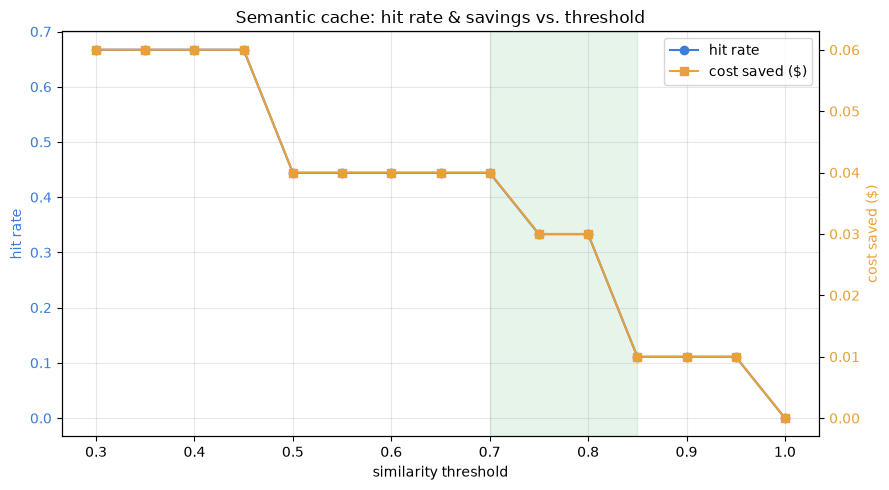

Saved threshold_tradeoff.png


In [4]:
import matplotlib.pyplot as plt

def run(threshold):
    c = SemanticCache(threshold=threshold, cost_per_call=0.01)
    for q in SAMPLE_QUERIES: c.ask(q)
    return c.summary()

ths = [round(x/20, 2) for x in range(6, 21)]
hit_rates = [run(t)["hit_rate"] for t in ths]
saved = [run(t)["cost_saved"] for t in ths]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(ths, hit_rates, marker="o", color="#3b7dd8", label="hit rate")
ax1.set_xlabel("similarity threshold"); ax1.set_ylabel("hit rate", color="#3b7dd8")
ax1.tick_params(axis="y", labelcolor="#3b7dd8"); ax1.grid(alpha=0.3)
ax1.axvspan(0.7, 0.85, color="#3aa757", alpha=0.12, label="typical safe zone")

ax2 = ax1.twinx()
ax2.plot(ths, saved, marker="s", color="#e8a13a", label="cost saved ($)")
ax2.set_ylabel("cost saved ($)", color="#e8a13a"); ax2.tick_params(axis="y", labelcolor="#e8a13a")

ax1.set_title("Semantic cache: hit rate & savings vs. threshold")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
plt.tight_layout()
plt.savefig("threshold_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved threshold_tradeoff.png")

## Summary

- A semantic cache reuses answers across **paraphrases**, where an exact-match cache would pay the model again.
- The **similarity threshold** trades savings for safety - too low returns wrong answers to near-miss questions; tune it on real traffic and log near-threshold hits.
- This demo's lexical embedder catches word overlap; real embeddings catch deeper meaning (e.g. "get" vs "request" a refund) - **swap `embed()` for a real embedding model in production** and keep everything else.
- Combine with a TTL / invalidation policy so cached answers don't go stale.
- Pairs with **Day 85 - LLM Cost Tracker** (measure what you saved) and **Day 90 - LLM Model Router** (route the misses to the right-sized model).

In [5]:
# --- Try your own -------------------------------------------------------
# Plug a real embedder and your own query log:
#
# def real_embed(text): return your_embedding_model(text)   # returns a dict/vector
# (then reuse cosine + SemanticCache, swapping embed -> real_embed)
#
# c = SemanticCache(threshold=0.82, cost_per_call=0.02)
# for q in ["reset password", "how to change my password", "reset password"]:
#     print(c.ask(q).hit)
print("Uncomment above to test your own stream / embedder.")

Uncomment above to test your own stream / embedder.


---
**Day 86 of Phoebe's FDE portfolio** · LLMOps & GenAI Platform

- 📦 Repo: [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)
- 🖥️ Streamlit version: `pip install -r requirements.txt && streamlit run app.py` (live threshold slider + sweep)